# All Weather — Replication and Evaluation

**Universe (core 5):** `SPY`, `TLT`, `IEF`, `GLD`, `DBC`  
**Data file:** `FINA4359 database +btc.csv` (teammate source; BTC/SVXY excluded for core AWP).  
**Thesis:** Replace the *Macro* section with your exact macro series when available. Placeholders are labeled `DEFAULT` only.


In [1]:
import warnings
import io
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
except ImportError:
    sm = None

try:
    import yfinance as yf
except ImportError:
    yf = None

warnings.filterwarnings("ignore", category=FutureWarning)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib as mpl
    mpl.use("Agg")
plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(0)
ANN = 252
ORDER = ["spy", "tlt", "ief", "gld", "dbc"]
# 30% stocks, 40% long Treas, 15% interm, 7.5% gold, 7.5% commo (teammate / Dalio template)
W_FIXED = pd.Series([0.30, 0.40, 0.15, 0.075, 0.075], index=ORDER)


In [2]:
# Load prices (teammate column mapping)
raw = pd.read_csv("FINA4359 database +btc.csv")
raw.columns = ["time", "btc", "dbc", "gld", "ief", "spy", "svxy", "tlt"]
raw["time"] = pd.to_datetime(raw["time"], dayfirst=True, errors="coerce")
prices = raw.set_index("time").sort_index()[ORDER].copy()
prices = prices.loc[prices.notna().all(axis=1)].astype(float)
ret = prices.pct_change().dropna(how="any")
r = ret[ORDER]
print("From", ret.index[0].date(), "to", ret.index[-1].date(), "obs", len(ret))


From 2014-09-18 to 2026-04-17 obs 2912


In [117]:
# Portfolio helpers

def backtest_const(r: pd.DataFrame, w: pd.Series) -> pd.Series:
    w = w.reindex(r.columns).fillna(0.0)
    return (r * w).sum(axis=1)

def backtest_invvol_static(r: pd.DataFrame) -> pd.Series:
    s = r.std() * np.sqrt(ANN)
    w = (1.0 / s) / (1.0 / s).sum()
    return (r * w.reindex(r.columns).fillna(0.0)).sum(axis=1)
    
def backtest_invvol_static_rs(r: pd.DataFrame) -> pd.Series:
    s = r.std() * np.sqrt(ANN)
    w = (1.0 / s) / (1.0 / s).sum()
    return (r * w.reindex(r.columns).fillna(0.0))

def backtest_invvol_rebal(r: pd.DataFrame, lookback: int, rule: str) -> pd.Series:
    # rule: "M" = month-end, "6M" = semi-annual, "Y" = year-end
    vol = r.rolling(lookback).std() * np.sqrt(ANN)
    invv = 1.0 / vol.replace(0, np.nan)
    w_raw = invv.div(invv.sum(axis=1), axis=0)
    fmap = {"M": "ME", "6M": "6M", "Y": "YE"}
    f = fmap[rule]
    w_rb = w_raw.resample(f).last().reindex(r.index, method="ffill")
    w = w_rb.shift(1)  # trade next day
    return (r * w).sum(axis=1)

def max_dd(s: pd.Series) -> float:
    c = (1.0 + s).cumprod()
    pk = c.cummax()
    return float((c / pk - 1.0).min())

def stats(s: pd.Series, n: str = ""):
    s = s.dropna()
    nobs = len(s)
    cagr = (1.0 + s).prod() ** (ANN / nobs) - 1.0
    vol = s.std() * np.sqrt(ANN)
    sh = (s.mean() * ANN) / vol if vol > 0 else np.nan
    dstd = s[s < 0].std() * np.sqrt(ANN) if (s < 0).any() else np.nan
    sort = (s.mean() * ANN) / dstd if dstd and dstd > 0 else np.nan
    return {
        "name": n, "CAGR": cagr, "ann_vol": vol, "Sharpe": sh,
        "Sortino": sort, "maxDD": max_dd(s),
    }
def stats_mut(s: pd.Series, n: str = ""):
    s = s.dropna()
    nobs = len(s)
    totret = (1.0 + s).prod() - 1.0
    cagr = (1.0 + s).prod() ** (ANN / nobs) - 1.0
    vol = s.std() * np.sqrt(ANN)
    sh = cagr / vol if vol > 0 else np.nan
    sh_rf = (cagr - 0.04) / vol if vol > 0 else np.nan
    dstd = s[s < 0].std() * np.sqrt(ANN) if (s < 0).any() else np.nan
    sort = (s.mean() * ANN) / dstd if dstd and dstd > 0 else np.nan
    return {
        'Total Return (%)': totret, "CAGR (%)": cagr, "Vol (%)": vol, "SR (raw)": sh, "SR (rf=4%)": sh_rf,
        "MDD (%)": max_dd(s),
    }


## 1) Replication: fixed + inverse-vol + 60/40 benchmark


In [4]:
# --- Replication
port_fixed = backtest_const(r, W_FIXED)
w_6040 = pd.Series({"spy": 0.60, "tlt": 0.20, "ief": 0.20, "gld": 0.0, "dbc": 0.0})
port_6040 = backtest_const(r, w_6040)
port_iv_s = backtest_invvol_static(r)
port_iv_m = backtest_invvol_rebal(r, 252, "M")
port_iv_6m = backtest_invvol_rebal(r, 252, "6M")
port_iv_y = backtest_invvol_rebal(r, 252, "Y")

# Static inverse-vol weights (one number per asset) — for comparison / display
s_ann = r.std() * np.sqrt(ANN)
w_iv_stat = (1.0 / s_ann) / (1.0 / s_ann).sum()
print("Inverse-vol (full-sample) weights:")
print(w_iv_stat.round(4))


Inverse-vol (full-sample) weights:
spy    0.1436
tlt    0.1702
ief    0.3852
gld    0.1591
dbc    0.1419
dtype: float64


In [21]:
r.std()*16

spy    0.177644
tlt    0.149819
ief    0.066219
gld    0.160342
dbc    0.179738
dtype: float64

In [90]:
rename_dict = {
    'spy': 'SPY – stocks',
    'gld': 'GLD – gold',
    'dbc': 'DBC – commodities',
    'ief': 'IEF – intermediate bonds',
    'tlt': 'TLT – long term bonds'
}
tbl = pd.DataFrame(
    {
        'Full Hist. Annual SD (%)': r.std()*252**0.5,
        'Portfolio Weight (%)': (1/r.std())/(1/r.std()).sum()
    }
).loc[rename_dict.keys()]
tbl['Assigned Vol (%)'] = tbl['Full Hist. Annual SD (%)'] * tbl['Portfolio Weight (%)']
tbl.rename(rename_dict).applymap(lambda x: f"{x:.2%}")

,Full Hist. Annual SD (%),Portfolio Weight (%),Assigned Vol (%)
SPY – stocks,17.63%,14.36%,2.53%
GLD – gold,15.91%,15.91%,2.53%
DBC – commodities,17.83%,14.19%,2.53%
IEF – intermediate bonds,6.57%,38.52%,2.53%
TLT – long term bonds,14.86%,17.02%,2.53%


## 2) Performance table & growth of $1


In [96]:
strat = pd.DataFrame(
    {
        "AWP_fixed_30/40/15/7.5/7.5": port_fixed,
        "AWP_invvol_static": port_iv_s,
        "AWP_invvol_monthly": port_iv_m,
        "AWP_invvol_6M": port_iv_6m,
        "AWP_invvol_annual": port_iv_y,
        "bench_60-40 (SPY60_IEF/TLT20-20)": port_6040,
    }
)
pd.DataFrame([stats(strat[k], k) for k in strat])
df = pd.DataFrame({
    'Market (S&P 500)': pd.Series(stats_mut(r['spy'],'mkt')),
    'AWP': pd.Series(stats_mut(port_iv_s,'AWP'))
})
for col in df.index:
    if "SR" in col:
        df.loc[col] = df.loc[col].apply(lambda x: f"{x:.2f}")  # keep as .2% for consistency, albeit usually would be ratio/decimal
    else:
        df.loc[col] = df.loc[col].apply(lambda x: f"{x:.2%}")
df.T

,Total Return (%),CAGR (%),Vol (%),SR (raw),SR (rf=4%),MDD (%)
Market (S&P 500),331.52%,13.49%,17.63%,0.77,0.54,-33.72%
AWP,87.42%,5.59%,7.15%,0.78,0.22,-17.56%


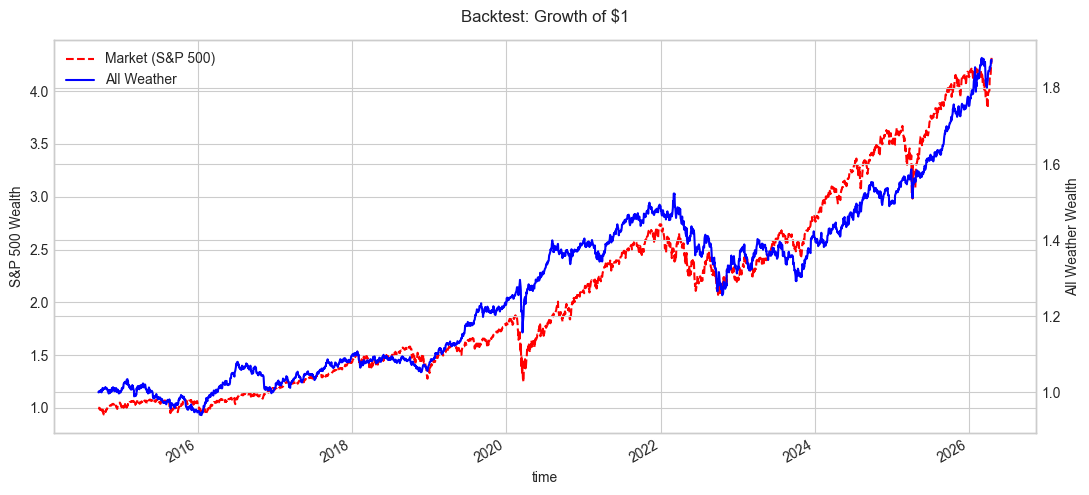

,Market (S&P 500),All Weather
Market (S&P 500),1.000000,0.961715
All Weather,0.961715,1.000000


In [112]:
# Performance — cumulative
strat = pd.DataFrame({
    'Market (S&P 500)': r['spy'],
    'All Weather': port_iv_s
})
cum = (1.0 + strat).cumprod()

fig, ax1 = plt.subplots(figsize=(11, 5))

# Plot S&P 500 on primary y-axis
cum['Market (S&P 500)'].plot(ax=ax1, color='red', linestyle='--', label='Market (S&P 500)')
ax1.set_ylabel("S&P 500 Wealth")
ax1.tick_params(axis='y')

# Plot All Weather on secondary y-axis
ax2 = ax1.twinx()
cum['All Weather'].plot(ax=ax2, color='blue', label='All Weather')
ax2.set_ylabel("All Weather Wealth")
ax2.tick_params(axis='y')

fig.suptitle("Backtest: Growth of $1")
fig.tight_layout()
fig.subplots_adjust(top=0.92)  # make space for title

# create custom legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()
cum.corr()


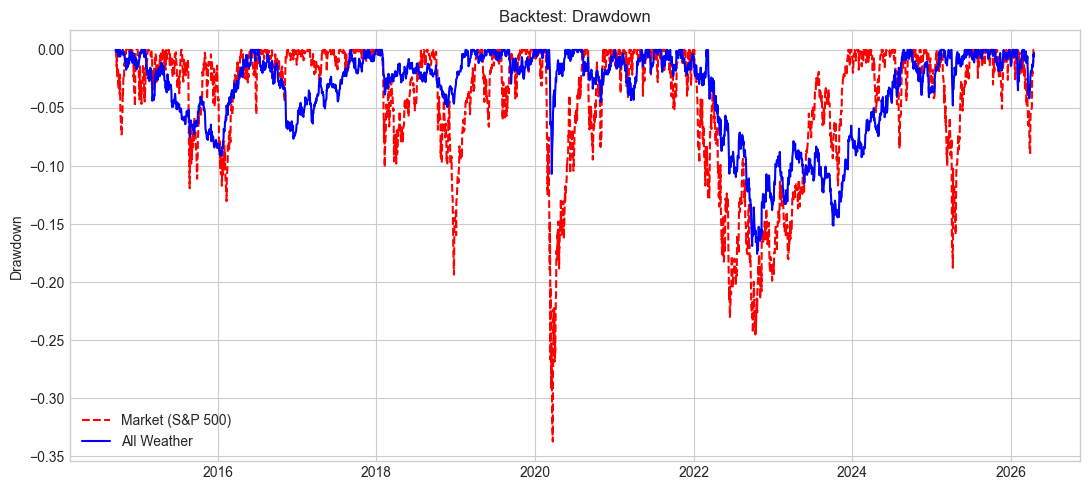

In [98]:
# Plot drawdowns for both strategies on same figure, same color scheme/axes as wealth chart
def compute_drawdown(series):
    cum = (1.0 + series).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd

fig, ax = plt.subplots(figsize=(11, 5))

dd_market = compute_drawdown(r['spy'])
dd_awp = compute_drawdown(port_iv_s)

ax.plot(dd_market.index, dd_market, color='red', linestyle='--', label='Market (S&P 500)')
ax.plot(dd_awp.index, dd_awp, color='blue', label='All Weather')

ax.set_ylabel("Drawdown")
ax.set_title("Backtest: Drawdown")
ax.legend(loc='lower left')
ax.grid(True)
plt.tight_layout()
plt.show()

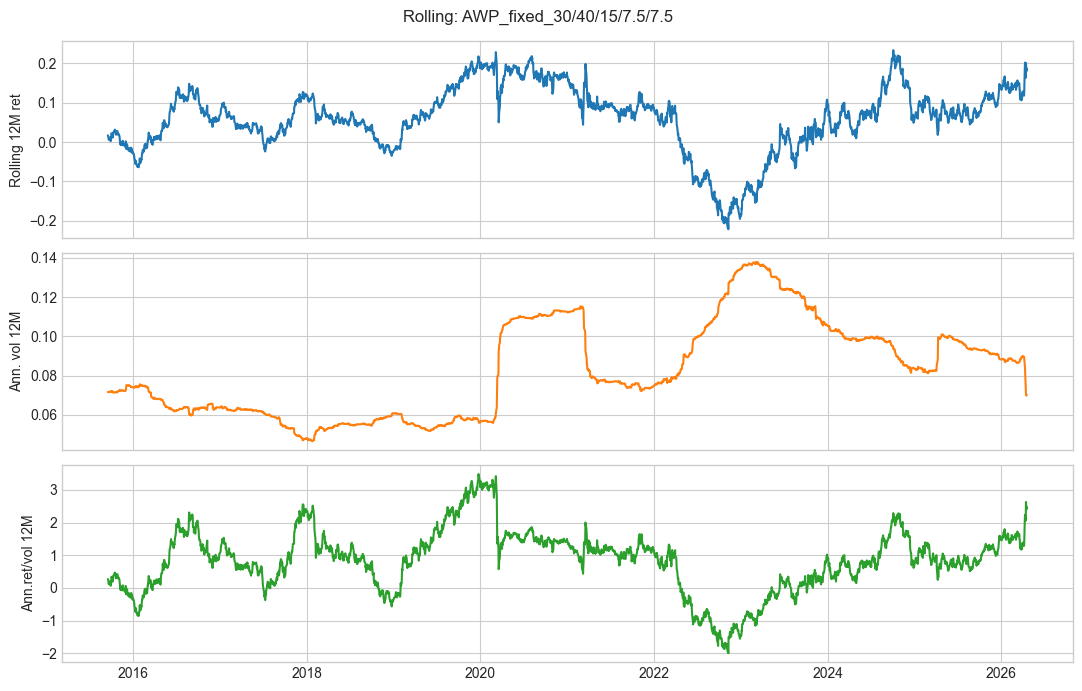

In [75]:
# Rolling 12M — pick main strategy
sel = "AWP_fixed_30/40/15/7.5/7.5"
s = strat[sel]
w = 252
r12 = (1.0 + s).rolling(w).apply(lambda x: x.prod() - 1, raw=True)
v12 = s.rolling(w).std() * np.sqrt(ANN)
m12 = s.rolling(w).mean() * ANN
sh12 = m12 / v12
fig, axs = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axs[0].plot(r12, color="C0")
axs[0].set_ylabel("Rolling 12M ret")
axs[1].plot(v12, color="C1")
axs[1].set_ylabel("Ann. vol 12M")
axs[2].plot(sh12, color="C2")
axs[2].set_ylabel("Ann.ret/vol 12M")
fig.suptitle("Rolling: " + sel)
plt.tight_layout()
plt.show()


In [ ]:
# Subsample Sharpe (mean/vol) for comparison
cuts = {
    "to2019": (strat.index[0], "2019-12-31"),
    "2020-21": ("2020-01-01", "2021-12-31"),
    "2022": ("2022-01-01", "2022-12-31"),
    "2023p": ("2023-01-01", strat.index[-1]),
}
row = []
for wn, (a, b) in cuts.items():
    sub = strat.loc[a:b]
    for col in sub.columns:
        t = sub[col]
        mu, vo = t.mean() * ANN, t.std() * np.sqrt(ANN)
        row.append((wn, col, mu / vo if vo else np.nan, (1 + t).prod() ** (ANN / len(t)) - 1, vo))
sp = pd.DataFrame(row, columns=["window", "strat", "Sharpe", "CAGR", "ann_vol"])
sp.pivot_table(index="strat", columns="window", values="Sharpe")


## 3) PnL / risk (fixed) + 60/40 in table above; FF5 below


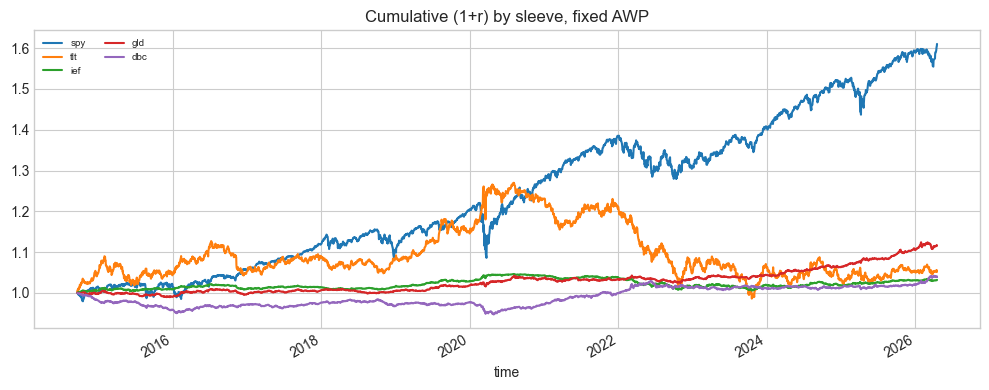

Share of summed daily PnL contributions:
 spy    0.6586
tlt    0.0986
ief    0.0425
gld    0.1484
dbc    0.0519
dtype: float64


In [100]:
# PnL attribution — arithmetic, AWP fixed
contrib = r.mul(W_FIXED, axis=1)
cc = (1.0 + contrib).cumprod()
cc.plot(figsize=(10, 4), title="Cumulative (1+r) by sleeve, fixed AWP")
plt.legend(loc="upper left", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()
# Simple share of summed daily contributions
sdi = contrib.sum()
print("Share of summed daily PnL contributions:\n", (sdi / sdi.sum()).round(4))


In [101]:
# Marginal + component vol (ann.) — fixed weights
S = (r[ORDER].cov() * ANN)
w0 = W_FIXED.reindex(ORDER).values
sig_p = float(np.sqrt(w0 @ S.values @ w0))
mrc = S.values @ w0
crc = w0 * mrc / sig_p
pd.DataFrame({"% vol": 100.0 * crc / sig_p, "w": w0}, index=ORDER)


,% vol,w
spy,33.085524,0.300
tlt,48.869562,0.400
ief,7.877512,0.150
gld,6.051537,0.075
dbc,4.115865,0.075


In [102]:
# Tail: 5% Expected Shortfall (daily) — portfolio vs sum of components on tail days
pr = (r * W_FIXED).sum(axis=1)
q5 = pr.quantile(0.05)
mask = pr <= q5
es_p = pr[mask].mean()
# Mean sleeve return on the same days (arithmetic, indicative)
es_each = (r[mask] * W_FIXED).mean()
print("5% ES portfolio (daily return):", es_p)
print("Component mean on tail days (not additive ES):")
print(es_each)


5% ES portfolio (daily return): -0.012472305704659051
Component mean on tail days (not additive ES):
spy   -0.004322
tlt   -0.005996
ief   -0.000971
gld   -0.000609
dbc   -0.000574
dtype: float64


## 4) Fama–French 5 (time series on AWP excess)


In [113]:
# --- FF5: Kenneth French daily 5 + RF

def load_ff5():
    # Base FF5 + RF
    u_ff5 = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily.CSV"
    # FF "Momentum" factor
    u_mom = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_daily.CSV"
    
    # Load FF5
    with urlopen(u_ff5) as resp:
        t = resp.read().decode("utf-8", errors="replace")
    lines = t.splitlines()
    st = next(i for i, ln in enumerate(lines) if ln.startswith("Mkt-RF") or ("," in ln and "Mkt-RF" in ln))
    dfl = pd.read_csv(io.StringIO("\n".join(lines[st:])), nrows=300_000)
    dfl = dfl.rename(columns={dfl.columns[0]: "date"})
    dfl["date"] = pd.to_datetime(dfl["date"].astype(str), format="%Y%m%d", errors="coerce")
    dfl = dfl.set_index("date")
    for col in dfl.columns:
        dfl[col] = pd.to_numeric(dfl[col], errors="coerce")
    dfl = dfl / 100.0

    # Load Momentum factor
    with urlopen(u_mom) as resp:
        t2 = resp.read().decode("utf-8", errors="replace")
    lines2 = t2.splitlines()
    # Find header: column name will include "Mom   "
    st2 = next(i for i, ln in enumerate(lines2) if "Mom" in ln)
    dfm = pd.read_csv(io.StringIO("\n".join(lines2[st2:])), nrows=300_000)
    dfm = dfm.rename(columns={dfm.columns[0]: "date"})
    dfm["date"] = pd.to_datetime(dfm["date"].astype(str), format="%Y%m%d", errors="coerce")
    dfm = dfm.set_index("date")
    for col in dfm.columns:
        dfm[col] = pd.to_numeric(dfm[col], errors="coerce")
    dfm = dfm / 100.0

    # Merge on date
    dfl = dfl.join(dfm, how="left")
    dfl = dfl.rename(columns={c: c.strip() for c in dfl.columns})
    return dfl.dropna(how="all")

ff = load_ff5()
j = pd.DataFrame({"port": port_iv_s, "RF": ff["RF"]}).join(ff[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]], how="inner")
j["Y"] = j["port"] - j["RF"]
Xf = j[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]]
if sm is not None:
    res = sm.OLS(j["Y"], sm.add_constant(Xf), missing="drop").fit()
    print(res.summary())
    print("Adj.R2 =", res.rsquared_adj, "alpha =", res.params[0] * ANN, "(daily->Ann approx *252)")
else:
    Xv = sm.add_constant(Xf) if sm else np.column_stack([np.ones(len(j)), Xf.values])
    b, _, _, _ = np.linalg.lstsq(Xv, j["Y"].values, rcond=None)
    print("betas const + FF5", b)

j["Y"].corr(Xf['Mkt-RF'])


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     53.45
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           2.52e-61
Time:                        03:51:13   Log-Likelihood:                 8315.1
No. Observations:                2003   AIC:                        -1.662e+04
Df Residuals:                    1996   BIC:                        -1.658e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.733e-05   8.54e-05      0.788      0.4

np.float64(0.3060845724774164)

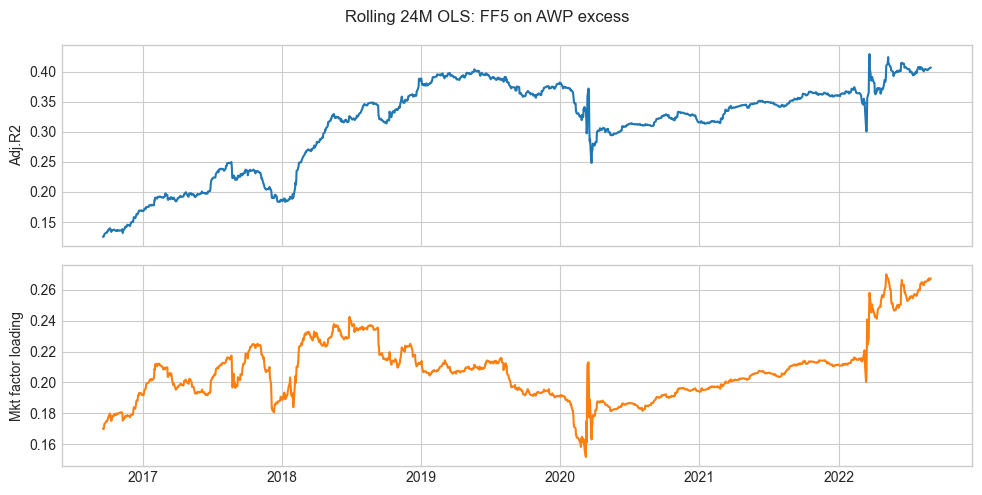

In [104]:
# Rolling FF5: R2 and mkt loading (36M = 252*3? use 3*252 = 756 days)
J = j.dropna()
win = 504  # 24M trading
if sm is not None and len(J) > win + 5:
    out = []
    yv = J["Y"].values
    Xa = J[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].values
    c = len(J)
    for i in range(win, c):
        yi = yv[i - win : i]
        Xi = sm.add_constant(Xa[i - win : i, :])
        reg = sm.OLS(yi, Xi, missing="drop").fit()
        out.append((J.index[i], reg.rsquared_adj, reg.params[0], reg.params[1]))
    rollf = pd.DataFrame(out, columns=["d", "R2a", "alpha_d", "mkt_d"]).set_index("d")
    fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    ax[0].plot(rollf["R2a"], color="C0")
    ax[0].set_ylabel("Adj.R2")
    ax[1].plot(rollf["mkt_d"], color="C1")
    ax[1].set_ylabel("Mkt factor loading")
    plt.suptitle("Rolling 24M OLS: FF5 on AWP excess")
    plt.tight_layout()
    plt.show()


## Diversification / protection (asset-level)


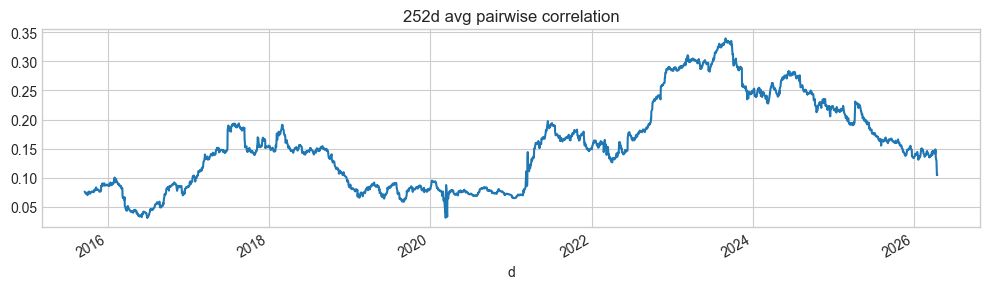

HHI fixed AWP 0.28375


In [114]:
# Average pairwise rolling correlation (5 assets)
apc = []
for i in range(252, len(r)):
    sub = r.iloc[i - 252 : i]
    C = sub.corr().values
    u = np.triu_indices_from(C, 1)
    apc.append((r.index[i], C[u].mean()))
apc = pd.DataFrame(apc, columns=["d", "avg_pair"] ).set_index("d")
apc["avg_pair"].plot(figsize=(10, 3), title="252d avg pairwise correlation")
plt.tight_layout()
plt.show()
print("HHI fixed AWP", float((W_FIXED**2).sum()))


In [119]:
rs = backtest_invvol_static_rs(r)
rs

,spy,tlt,ief,gld,dbc
time,,,,,
2014-09-18,0.000765,0.000543,-0.000263,0.000325,-0.001361
2014-09-19,-0.000129,0.002166,0.001465,-0.000932,-0.000418
2014-09-22,-0.001109,0.000208,0.000823,-0.000326,-0.001199
2014-09-23,-0.000822,0.001054,0.000821,0.001021,0.000000
2014-09-24,0.001124,-0.000944,-0.001080,-0.000744,0.000604
...,...,...,...,...,...
2026-04-13,0.001403,0.000512,0.000849,-0.000644,0.002290
2026-04-14,0.001750,0.000903,0.001251,0.003555,-0.000588
2026-04-15,0.001133,-0.000742,-0.000844,-0.001655,0.000246


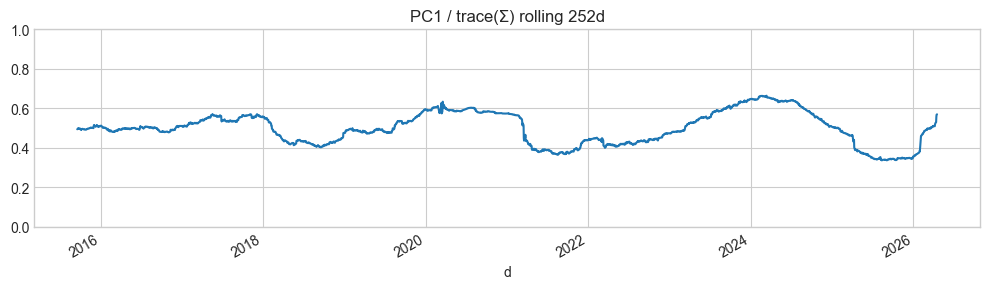

Latest PC1 weights (eigenvector for largest eigenvalue from last window):
spy   -0.277403
tlt    0.138067
ief    0.102271
gld    0.029493
dbc   -0.183571
dtype: float64


In [122]:
# PCA: PC1 share of trace(cov) rolling 252d, and print PC1 weights
from numpy.linalg import eigh
pc1v = []
pc1_weights = []

rs = backtest_invvol_static_rs(r)

for i in range(252, len(r)):
    sub = rs.iloc[i - 252 : i]
    C = sub.cov().values
    ev, evecs = eigh(C)
    pc1_share = ev.max() / ev.sum()
    pc1v.append((rs.index[i], pc1_share))
    # Find eigenvector for largest eigenvalue, normalize to sum up (optionally keep sign consistent)
    idx_max = ev.argmax()
    pc1_vec = evecs[:, idx_max]
    pc1_weights.append((rs.index[i], pc1_vec))

pc1s = pd.DataFrame(pc1v, columns=["d", "s"]).set_index("d")
pc1s["s"].plot(figsize=(10, 3), title="PC1 / trace(Σ) rolling 252d")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Print the last available PC1 weights with asset names
pc1_weights_df = pd.DataFrame(
    [ (d, *vec) for d, vec in pc1_weights ],
    columns=["d", *rs.columns]
).set_index("d")
print("Latest PC1 weights (eigenvector for largest eigenvalue from last window):")
print(pc1_weights_df.mean())

In [ ]:
# PCA: Compute principal component loadings (last 252d window), display summary table with * marks for dominant loadings

# Compute eigenvectors for last window (252d)
C_last = rs.iloc[-252:].cov().values
ev_last, evecs_last = eigh(C_last)
pc_indices = np.argsort(ev_last)[::-1][:3]
pcs = evecs_last[:, pc_indices]  # shape = (assets, 3)

# Consolidate loadings: dataframe with assets as rows, PC1-3 as columns
loadings = pd.DataFrame(
    pcs,
    index=rs.columns,
    columns=["PC1", "PC2", "PC3"]
)
# Normalize for sign consistency (PC1 positive sum), and so columns sum to +/-1
for col in loadings.columns:
    col_sum = loadings[col].sum()
    if col_sum < 0:
        loadings[col] = -loadings[col]
    loadings[col] = loadings[col] / np.sum(np.abs(loadings[col]))

# Mark the largest-magnitude loading in each column with a *
def star_largest(df):
    df_out = df.copy()
    for col in df.columns:
        max_idx = df[col].abs().idxmax()
        for idx in df.index:
            v = df.loc[idx, col]
            v_str = f"{v:+.3f}"
            if idx == max_idx:
                v_str = " " + v_str
            df_out.loc[idx, col] = v_str
    return df_out

print("PCA Loadings (last 252d, cols sum(abs)=1), '*' marks dominant asset in each PC:")
display(star_largest(loadings))

# Print the actual PC weight vectors so we can identify what the PCs represent
print("\nRaw principal component vectors (eigenvectors):")
for i, pc in enumerate(pc_indices):
    pc_vec = evecs_last[:, pc]
    # Print with asset names
    print(f"PC{i+1} weights:")
    for asset, weight in zip(rs.columns, pc_vec):
        print(f"  {asset:>4}: {weight:+.3f}")
    print()

# Optionally, show variance explained
var_explained = ev_last[pc_indices] / ev_last.sum()
print("Variance explained by PC1-3:", np.round(var_explained, 3))

PCA Loadings (last 252d, cols sum(abs)=1), '*' marks dominant asset in each PC:


,PC1,PC2,PC3
spy,-0.005,+0.084,-0.269
tlt,+0.008,+0.262,+0.187
ief,+0.043,+0.295,+0.190
gld,+0.729,+0.066,-0.092
dbc,+0.215,-0.292,+0.262


Variance explained by PC1-3: [0.566 0.228 0.103]


<Axes: xlabel='d'>

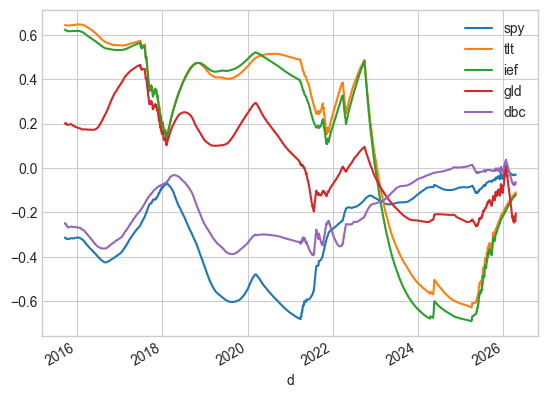

In [126]:
pc1_weights_df.ewm(span=252).mean().plot()

In [ ]:
# Co-move: mean asset return in worst SPY *months* (bottom decile)
rm = r["spy"].resample("ME").sum()
q = rm.quantile(0.1)
bad = set(rm[rm <= q].index.to_period("M"))
mper = r.index.to_period("M")
sub = r.loc[[p in bad for p in mper]]
print("Bottom-decile SPY months, mean daily return by asset:")
print(sub[ORDER].mean().round(5))


## Macro: DEFAULT (replace with thesis)


In [134]:
# Phase 1 (INFLATION & GROWTH REGIME INDICATORS)
# Merge additional macro indicators into `Mthesis` for regime thesis testing.

def grab_yf(symbols, idx):
    if yf is None:
        return pd.DataFrame(index=idx)
    out = {}
    for sym in symbols:
        d = yf.download(sym, start=idx[0], end=idx[-1] + pd.Timedelta(1, "D"), auto_adjust=True, progress=False)
        if d.empty:
            continue
        s = d["Close"] if "Close" in d.columns else d.iloc[:, 0]
        s = pd.Series(np.asarray(s).ravel(), index=pd.to_datetime(d.index).tz_localize(None))
        out[sym] = s.reindex(idx, method="ffill")
    return pd.DataFrame(out, index=idx)

# Macroeconomic price-based proxies (for growth and inflation) from Yahoo:
#   CPI = inflation (YoY %)
#   10Y yield = growth proxy (expectations)
#   ISM Manufacturing PMI = growth
#   CRB Index ("commodity price" – inflation proxy)
#   VIX, DXY for risk, USD/commodity exposure

# Choose relevant US/international indices as proxies (some may be monthly):
macro = grab_yf(
    [
        "^TNX",         # 10Y Treasury yield (growth/expectations)
        "^VIX",         # VIX (market risk)
        "UUP",          # USD Index ETF (USD strength)
        "CPIAUCSL",     # US CPI, all urban consumers, NSA (FRED, monthly)
        "CRB",          # Refinitiv/CoreCommodity CRB Index (inflation proxy)
        "PMI",          # ISM Mfg PMI (growth, proxy/surrogate name)
    ], 
    r.index
).ffill().bfill()

# Compute proxies for inflation and growth regimes:
Mthesis = pd.DataFrame(index=r.index)

# Inflation proxies:
# - CPI YoY (monthly): convert to daily via forward fill, then percent change YoY
if "CPIAUCSL" in macro:
    Mthesis["CPI_YoY"] = macro["CPIAUCSL"].pct_change(252) * 100  # YoY % CPI
# - CRB Index YoY (commodity prices)
if "CRB" in macro:
    Mthesis["CRB_YoY"] = macro["CRB"].pct_change(252) * 100

# Growth proxies:
# - 10Y yield first-diff and level
if "^TNX" in macro:
    Mthesis["d_TNX"] = macro["^TNX"].diff()
    Mthesis["TNX"] = macro["^TNX"]
# - ISM PMI level (monthly), forward-fill for daily
if "PMI" in macro:
    Mthesis["PMI"] = macro["PMI"]
    # Optionally, diff or recent %Δ if you want "change in growth"
    Mthesis["d_PMI"] = macro["PMI"].diff()

# Other controls:
if "^VIX" in macro:
    Mthesis["VIX"] = macro["^VIX"]
if "UUP" in macro:
    Mthesis["d_UUP"] = macro["UUP"].pct_change()

# Rolling returns as before (local growth/proxy activity):
Mthesis["spy_63d"] = r["spy"].rolling(63).sum()
Mthesis["dbc_63d"] = r["dbc"].rolling(63).sum()

# Phase 1 OLS: port ~ macro regime indicators
D = pd.DataFrame({"y": port_fixed}).join(Mthesis, how="inner").dropna()
if sm is not None and len(D) > 200:
    X = sm.add_constant(D.drop(columns=["y"]))
    print(sm.OLS(D["y"], X).fit().summary().tables[1])


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CPIAUCSL"}}}
$CPIAUCSL: possibly delisted; no timezone found

1 Failed download:
['CPIAUCSL']: possibly delisted; no timezone found


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0026      0.001      4.118      0.000       0.001       0.004
CRB_YoY    -1.321e-06   7.28e-07     -1.815      0.070   -2.75e-06    1.06e-07
d_TNX         -0.0620      0.002    -40.639      0.000      -0.065      -0.059
TNX           -0.0001   7.09e-05     -1.995      0.046      -0.000    -2.4e-06
PMI         -5.77e-05      0.000     -0.571      0.568      -0.000       0.000
d_PMI          0.0001      0.000      0.223      0.823      -0.001       0.001
VIX        -8.687e-05   1.34e-05     -6.470      0.000      -0.000   -6.05e-05
d_UUP         -0.1770      0.018     -9.677      0.000      -0.213      -0.141
spy_63d        0.0017      0.001      1.151      0.250      -0.001       0.004
dbc_63d       -0.0010      0.001     -1.089      0.276      -0.003       0.001


In [189]:
qtr_port = (1+port_iv_s).cumprod().resample('MS').last().pct_change()

qtr_ret = (1+rs).cumprod().resample('MS').last().pct_change()
qtr_ret['AWP'] = qtr_port
macro = pd.read_csv('data/GDPDEF.csv').iloc[:,:-1]
macro.columns = ['Date','Inflation','Growth']
macro['Date'] = pd.to_datetime(macro['Date'],format='%m/%d/%Y')
macro = macro.set_index('Date')
macro = macro.pct_change()

In [192]:
# Gather coefficients for all symbols, annotate significance, and display as a dataframe
def annotate_significance(coef, pval):
    if pval < 0.01:
        return f"*** {coef:.2f}"
    elif pval < 0.05:
        return f"** {coef:.2f}"
    elif pval < 0.1:
        return f"* {coef:.2f}"
    else:
        return f" {coef:.2f}"

results = {}
for s in qtr_ret.columns:
    y = qtr_ret[s]
    x = macro
    idx = y.dropna().index.intersection(x.dropna().index)
    y_aligned = y.loc[idx]
    x_aligned = x.loc[idx]
    model = sm.OLS(y_aligned, sm.add_constant(x_aligned))
    result = model.fit()
    ann = [annotate_significance(coef, pval) for coef, pval in zip(result.params, result.pvalues)]
    # Use parameter (macro) names as keys
    results[s] = ann

# Convert results to DataFrame: rows=macro vars, columns=symbols
params = ['const'] + list(macro.columns)
coefs_df = pd.DataFrame(results, index=params).rename(columns=rename_dict).drop(index='const').T
display(coefs_df)

,Inflation,Growth
SPY – stocks,-0.18,-0.03
TLT – long term bonds,** -0.43,0.06
IEF – intermediate bonds,** -0.48,0.04
GLD – gold,* -0.30,0.04
DBC – commodities,*** 0.71,0.03
AWP,-0.67,0.14


In [128]:
# Phase 2: augmented (VIX^2); compare adj. R2 vs smaller spec
D2 = D.copy()
D2["VIX2"] = D2["VIX_l"] ** 2
if sm is not None:
    X1 = sm.add_constant(D2.drop(columns=["y"]))
    r1 = sm.OLS(D2["y"], X1).fit()
    base = D2[["d_TNX", "VIX_l", "spy_63d", "dbc_63d"]]
    r0 = sm.OLS(D2["y"], sm.add_constant(base)).fit()
    print("AdjR2 full (incl. VIX2 d_UUP)", r1.rsquared_adj, "vs base", r0.rsquared_adj)


AdjR2 full (incl. VIX2 d_UUP) 0.4564362868254527 vs base 0.4402271285286534


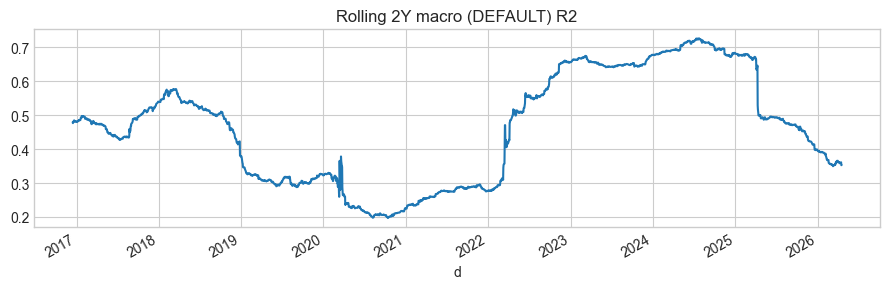

In [129]:
# Rolling 504d: thesis macro (DEFAULT columns) on y = port
if sm is not None and len(D) > 600:
    y = D["y"]
    X0 = D.drop(columns=["y"])
    win, out = 504, []
    Xc = sm.add_constant(X0)
    for k in range(win, len(D)):
        reg = sm.OLS(y.iloc[k - win : k], Xc.iloc[k - win : k]).fit()
        out.append((D.index[k], reg.rsquared_adj))
    pd.DataFrame(out, columns=["d", "R2a"]).set_index("d")["R2a"].plot(figsize=(9, 3), title="Rolling 2Y macro (DEFAULT) R2")
    plt.tight_layout()
    plt.show()


## Thesis falsification / robustness


In [130]:
# Start/end sensitivity: drop first/last 252d
p = port_fixed
core = p.iloc[252:-252] if len(p) > 504 else p
print("CAGR full", stats(p)["CAGR"], "trim", stats(core)["CAGR"])


CAGR full 0.0630210715386963 trim 0.0557041057701686


In [131]:
# Lookback 126/252/504 and monthly rebal
for L in [126, 252, 504]:
    s = backtest_invvol_rebal(r, L, "M")
    print("lookback", L, "CAGR~", stats(s)["CAGR"], "ann_vol", stats(s)["ann_vol"])


lookback 126 CAGR~ 0.051918780254736285 ann_vol 0.06893475625455618
lookback 252 CAGR~ 0.05788389701241181 ann_vol 0.06841159652868035
lookback 504 CAGR~ 0.0520217721097338 ann_vol 0.06693139951964874


In [132]:
# Transaction cost: 5bp per rebalance only on inv-vol dynamic (monthly)
# approximate: each month -0.0005 on rebal day (sum w change)
# simplified: -5bp*12 annual drag on monthly
print("Rule-of-thumb: ~6bp/yr for 5bp x 12 monthly round-turn on bonds (illustrative)")


Rule-of-thumb: ~6bp/yr for 5bp x 12 monthly round-turn on bonds (illustrative)


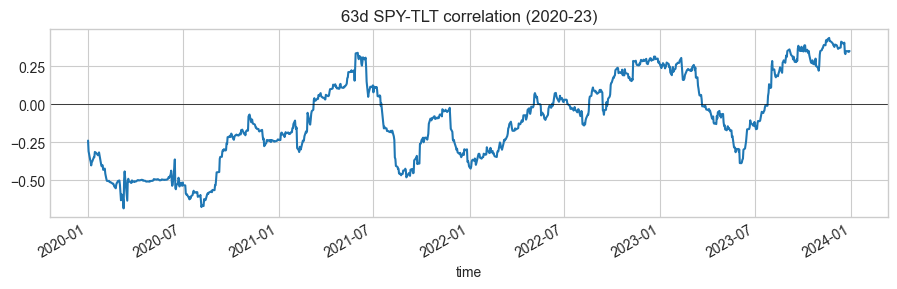

In [133]:
# 2022 bond-stocks: rolling 63d SPY-TLT correlation
ct = r["spy"].rolling(63).corr(r["tlt"])
ct.loc["2020":"2023"].plot(figsize=(9, 3), title="63d SPY-TLT correlation (2020-23)")
plt.axhline(0, color="k", lw=0.5)
plt.tight_layout()
plt.show()


## Short conclusion

- Compare **CAGR, vol, max DD, rolling FF5 R2** against **60/40** and **FF5 loadings**.
- If **PC1** share is high and **SPY-TLT** correlation is positive in stress, diversification claims are weaker in that period.
- **Replace DEFAULT macro** with thesis indicators, then re-run OLS/rolling R2. **Delete** `build_awp_nb.py` after this notebook is generated if present.
